# Chapter 95 - What This Tiny LLM Can and Cannot Do

The course built a real, inspectable language model from small components.

This chapter uses one controlled run to separate what that model demonstrates from capabilities it does not establish.

## Learning goals

By the end of this chapter, you will be able to:

- identify local pattern learning in generated text;
- distinguish lower next-token loss from factual accuracy or reasoning;
- explain why names and surface style are easier than coherent essays;
- demonstrate the model's context-window boundary;
- check a sample for exact overlap with its training corpus;
- distinguish GPT-style architecture from production capability; and
- describe which kinds of scale and training change model behavior.

## Define the claims carefully

A **local pattern** is a regularity over nearby tokens, such as spelling, spacing, punctuation, or a short phrase.

**Long-range coherence** means preserving participants, events, claims, and topic across a longer passage.

**Factual reliability** means answering factual questions accurately and consistently, including when wording changes.

**Reasoning reliability** means applying a procedure consistently rather than producing an answer-shaped string by chance.

**Scale** includes training data, parameter count, compute, context length, tokenizer design, and post-training.

A **production-level system** must meet measured requirements for reliability, safety, latency, monitoring, and maintenance in a specific application.

One generated sample can illustrate behavior, but it cannot establish reliability.

The audit below therefore supports narrow conclusions about this run only.

## Prepare a narrow training task

We will train on five short narrative paragraphs and hold out two different paragraphs.

The split happens before repetition so repeated validation prose cannot leak into training.

This corpus is suitable for learning local narrative patterns, not world knowledge, arithmetic procedures, or instruction following.

In [1]:
source_paragraphs = [
    "alice sat beside the quiet garden and watched a white rabbit cross the path.",
    "the rabbit stopped near the little door, looked back, and hurried into the hall.",
    "a lamp burned beside the window while rain moved softly across the dark glass.",
    "the old clock struck three, and clara listened for another sound behind the wall.",
    "in the morning the baker opened the shop and the cart rolled over the stones.",
    "a folded letter waited on the table with a small red seal and no written name.",
    "the river shone beyond the field, and the reeds bent low in the evening wind.",
]

print("paragraphs:", len(source_paragraphs))
print("example:", source_paragraphs[0])

paragraphs: 7
example: alice sat beside the quiet garden and watched a white rabbit cross the path.


A fixed shuffle makes the held-out paragraphs reproducible.

Repeating only the training portion makes a short CPU run possible, but it also raises memorization risk.

In [2]:
import random  # noqa: I001


paragraph_indexes = list(range(len(source_paragraphs)))
split_random = random.Random(95)
split_random.shuffle(paragraph_indexes)
validation_indexes = set(paragraph_indexes[:2])
training_paragraphs = [
    paragraph
    for index, paragraph in enumerate(source_paragraphs)
    if index not in validation_indexes
]
validation_paragraphs = [
    paragraph
    for index, paragraph in enumerate(source_paragraphs)
    if index in validation_indexes
]
training_source_text = "\n".join(training_paragraphs)
training_text = (training_source_text + "\n") * 10
validation_text = "\n".join(validation_paragraphs)

print("training paragraphs:", len(training_paragraphs))
print("held-out paragraphs:", len(validation_paragraphs))
print("repeated training characters:", len(training_text))
print("held-out characters:", len(validation_text))
print("held-out text:", validation_text)

training paragraphs: 5
held-out paragraphs: 2
repeated training characters: 3980
held-out characters: 155
held-out text: alice sat beside the quiet garden and watched a white rabbit cross the path.
a lamp burned beside the window while rain moved softly across the dark glass.


## Build a character tokenizer

The fixed vocabulary includes digits and question marks so the later audit prompts can be encoded.

Digits occur in prompts but not in the corpus, so their embeddings and output behavior receive no task-specific evidence during training.

That deliberate mismatch helps expose why an unsupported prompt should not be trusted.

In [3]:
import torch  # noqa: I001


device = "cpu"
characters = sorted(set("\n abcdefghijklmnopqrstuvwxyz,.!?;:'-0123456789"))
character_to_id = {
    character: character_id for character_id, character in enumerate(characters)
}
id_to_character = {
    character_id: character for character, character_id in character_to_id.items()
}


def encode_text(text: str) -> list[int]:
    unknown_characters = sorted(set(text) - set(character_to_id))
    if unknown_characters:
        raise ValueError(f"Unknown characters: {unknown_characters}")
    return [character_to_id[character] for character in text]


def decode_token_ids(token_ids: list[int]) -> str:
    return "".join(id_to_character[token_id] for token_id in token_ids)


training_ids = torch.tensor(encode_text(training_text), dtype=torch.long)
validation_ids = torch.tensor(encode_text(validation_text), dtype=torch.long)
vocabulary_size = len(characters)

assert decode_token_ids(training_ids.tolist()) == training_text
print("device:", device)
print("vocabulary size:", vocabulary_size)
print("training target characters:", repr("".join(sorted(set(training_text)))))

device: cpu
vocabulary size: 46
training target characters: '\n ,.abcdefghiklmnoprstuvwy'


Each batch pairs a context with the same sequence shifted one character ahead.

An explicit generator separates batch randomness from sampling randomness.

In [4]:
def sample_shifted_batch(
    token_ids: torch.Tensor,
    batch_size: int,
    context_length: int,
    generator: torch.Generator,
) -> tuple[torch.Tensor, torch.Tensor]:
    number_of_starts = len(token_ids) - context_length
    if number_of_starts < 1:
        raise ValueError("The token stream must be longer than the context.")
    starts = torch.randint(
        number_of_starts, (batch_size,), generator=generator
    ).tolist()
    input_rows = [token_ids[start : start + context_length] for start in starts]
    target_rows = [
        token_ids[start + 1 : start + context_length + 1] for start in starts
    ]
    return torch.stack(input_rows), torch.stack(target_rows)


batch_generator = torch.Generator().manual_seed(9501)
example_inputs, example_targets = sample_shifted_batch(
    training_ids, batch_size=3, context_length=16, generator=batch_generator
)
print("input shape:", tuple(example_inputs.shape))
print(
    "target shift correct:", torch.equal(example_inputs[:, 1:], example_targets[:, :-1])
)

input shape: (3, 16)
target shift correct: True


## Build the miniature GPT

The implementation contains learned token and position embeddings, causal multi-head self-attention, feedforward networks, residual connections, layer normalization, and an output projection.

These are real GPT-style building blocks.

Their presence describes the computation, not the trained system's reliability.

In [5]:
import math  # noqa: I001
import torch


class MultiHeadCausalSelfAttention(torch.nn.Module):
    embedding_dimension: int
    number_of_attention_heads: int
    head_size: int

    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        if embedding_dimension % number_of_attention_heads != 0:
            raise ValueError("Attention heads must divide the embedding dimension.")
        self.embedding_dimension = embedding_dimension
        self.number_of_attention_heads = number_of_attention_heads
        self.head_size = embedding_dimension // number_of_attention_heads
        self.query_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.key_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.value_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.output_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension
        )
        self.attention_dropout = torch.nn.Dropout(dropout_rate)
        self.output_dropout = torch.nn.Dropout(dropout_rate)
        self.register_buffer(
            "causal_mask",
            torch.tril(torch.ones(context_length, context_length, dtype=torch.bool)),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        batch_size, sequence_length, _ = input_values.shape

        def split_heads(values: torch.Tensor) -> torch.Tensor:
            return values.view(
                batch_size,
                sequence_length,
                self.number_of_attention_heads,
                self.head_size,
            ).transpose(1, 2)

        queries = split_heads(self.query_projection(input_values))
        keys = split_heads(self.key_projection(input_values))
        values = split_heads(self.value_projection(input_values))
        attention_scores = queries @ keys.transpose(-2, -1)
        attention_scores = attention_scores / math.sqrt(self.head_size)
        causal_mask = self.causal_mask[:sequence_length, :sequence_length]
        attention_scores = attention_scores.masked_fill(~causal_mask, float("-inf"))
        attention_weights = torch.softmax(attention_scores, dim=-1)
        attended_values = self.attention_dropout(attention_weights) @ values
        concatenated_values = (
            attended_values.transpose(1, 2)
            .contiguous()
            .view(batch_size, sequence_length, self.embedding_dimension)
        )
        projected_values = self.output_projection(concatenated_values)
        output_values: torch.Tensor = self.output_dropout(projected_values)
        return output_values

In [6]:
class FeedForwardNetwork(torch.nn.Module):
    def __init__(self, embedding_dimension: int, dropout_rate: float) -> None:
        super().__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(embedding_dimension, 4 * embedding_dimension),
            torch.nn.ReLU(),
            torch.nn.Linear(4 * embedding_dimension, embedding_dimension),
            torch.nn.Dropout(dropout_rate),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        output_values: torch.Tensor = self.network(input_values)
        return output_values


class TransformerBlock(torch.nn.Module):
    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        self.attention_norm = torch.nn.LayerNorm(embedding_dimension)
        self.attention = MultiHeadCausalSelfAttention(
            embedding_dimension=embedding_dimension,
            number_of_attention_heads=number_of_attention_heads,
            context_length=context_length,
            dropout_rate=dropout_rate,
        )
        self.feedforward_norm = torch.nn.LayerNorm(embedding_dimension)
        self.feedforward = FeedForwardNetwork(
            embedding_dimension=embedding_dimension,
            dropout_rate=dropout_rate,
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        attention_branch = self.attention(self.attention_norm(input_values))
        values_after_attention = input_values + attention_branch
        feedforward_branch = self.feedforward(
            self.feedforward_norm(values_after_attention)
        )
        output_values: torch.Tensor = values_after_attention + feedforward_branch
        return output_values


class TinyGPT(torch.nn.Module):
    vocabulary_size: int
    context_length: int

    def __init__(
        self,
        vocabulary_size: int,
        context_length: int,
        embedding_dimension: int,
        number_of_attention_heads: int,
        number_of_transformer_blocks: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        self.vocabulary_size = vocabulary_size
        self.context_length = context_length
        self.token_embedding = torch.nn.Embedding(vocabulary_size, embedding_dimension)
        self.position_embedding = torch.nn.Embedding(
            context_length, embedding_dimension
        )
        self.embedding_dropout = torch.nn.Dropout(dropout_rate)
        self.transformer_blocks = torch.nn.Sequential(
            *[
                TransformerBlock(
                    embedding_dimension=embedding_dimension,
                    number_of_attention_heads=number_of_attention_heads,
                    context_length=context_length,
                    dropout_rate=dropout_rate,
                )
                for _ in range(number_of_transformer_blocks)
            ]
        )
        self.final_norm = torch.nn.LayerNorm(embedding_dimension)
        self.output_layer = torch.nn.Linear(embedding_dimension, vocabulary_size)

    def forward(
        self,
        input_token_ids: torch.Tensor,
        target_token_ids: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        if input_token_ids.ndim != 2:
            raise ValueError("Inputs must have shape [batch, time].")
        batch_size, sequence_length = input_token_ids.shape
        if sequence_length > self.context_length:
            raise ValueError("Input exceeds model context length.")
        position_ids = torch.arange(sequence_length, device=input_token_ids.device)
        hidden_values = self.token_embedding(input_token_ids)
        hidden_values = hidden_values + self.position_embedding(position_ids)
        hidden_values = self.embedding_dropout(hidden_values)
        hidden_values = self.transformer_blocks(hidden_values)
        logits = self.output_layer(self.final_norm(hidden_values))
        loss = None
        if target_token_ids is not None:
            if target_token_ids.shape != input_token_ids.shape:
                raise ValueError("Targets must have the same shape as inputs.")
            loss = torch.nn.functional.cross_entropy(
                logits.reshape(batch_size * sequence_length, self.vocabulary_size),
                target_token_ids.reshape(batch_size * sequence_length),
            )
        return logits, loss

    @torch.no_grad()
    def generate(
        self,
        input_token_ids: torch.Tensor,
        number_of_new_tokens: int,
        generator: torch.Generator,
        temperature: float = 1.0,
        top_k: int | None = None,
    ) -> torch.Tensor:
        if temperature <= 0:
            raise ValueError("temperature must be positive.")
        generated_ids = input_token_ids
        for _ in range(number_of_new_tokens):
            model_input = generated_ids[:, -self.context_length :]
            logits, _ = self(model_input)
            next_logits = logits[:, -1] / temperature
            if top_k is not None:
                effective_top_k = min(top_k, self.vocabulary_size)
                top_values, _ = torch.topk(next_logits, effective_top_k)
                next_logits = next_logits.masked_fill(
                    next_logits < top_values[:, -1, None], float("-inf")
                )
            probabilities = torch.softmax(next_logits, dim=-1)
            next_ids = torch.multinomial(
                probabilities, num_samples=1, generator=generator
            )
            generated_ids = torch.cat([generated_ids, next_ids], dim=1)
        return generated_ids

The configuration is intentionally small enough for a short CPU exercise.

Parameter count, context length, and observed training data make its scale concrete.

In [7]:
context_length = 48
embedding_dimension = 48
number_of_attention_heads = 4
number_of_transformer_blocks = 2
dropout_rate = 0.1

torch.manual_seed(9502)
model = TinyGPT(
    vocabulary_size=vocabulary_size,
    context_length=context_length,
    embedding_dimension=embedding_dimension,
    number_of_attention_heads=number_of_attention_heads,
    number_of_transformer_blocks=number_of_transformer_blocks,
    dropout_rate=dropout_rate,
).to(device)
parameter_count = sum(parameter.numel() for parameter in model.parameters())

print("parameters:", f"{parameter_count:,}")
print("context length:", model.context_length, "characters")
print("unique source training characters:", len(training_source_text))
print("repeated characters used for batches:", len(training_text))

parameters: 63,118
context length: 48 characters
unique source training characters: 397
repeated characters used for batches: 3980


## Train and compare checkpoints

Cross-entropy loss measures next-character prediction on the sampled targets.

Held-out loss is more informative than training loss, but two paragraphs remain a very small validation set.

The same prompt and sampling seed at every checkpoint make the sample comparison controlled.

In [8]:
@torch.no_grad()
def estimate_loss(
    model: TinyGPT,
    token_ids: torch.Tensor,
    batch_size: int,
    context_length: int,
    number_of_batches: int,
    random_seed: int,
) -> float:
    model.eval()
    generator = torch.Generator().manual_seed(random_seed)
    losses: list[float] = []
    for _ in range(number_of_batches):
        input_batch, target_batch = sample_shifted_batch(
            token_ids, batch_size, context_length, generator
        )
        _, loss = model(input_batch, target_batch)
        if loss is None:
            raise RuntimeError("Evaluation requires targets.")
        losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)


@torch.no_grad()
def generate_text(
    model: TinyGPT,
    prompt: str,
    number_of_new_tokens: int,
    random_seed: int,
    temperature: float = 0.8,
    top_k: int | None = 20,
) -> str:
    model.eval()
    prompt_ids = encode_text(prompt)[-model.context_length :]
    input_ids = torch.tensor([prompt_ids], dtype=torch.long, device=device)
    generator = torch.Generator(device=device).manual_seed(random_seed)
    generated_ids = model.generate(
        input_ids,
        number_of_new_tokens=number_of_new_tokens,
        generator=generator,
        temperature=temperature,
        top_k=top_k,
    )
    return decode_token_ids(generated_ids[0].tolist())

In [9]:
training_steps = 350
evaluation_steps = [0, 100, 200, 350]
training_loss_history: list[float] = []
validation_loss_history: list[float] = []
checkpoint_samples: dict[int, str] = {}
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
training_generator = torch.Generator().manual_seed(9503)

for step in range(training_steps + 1):
    if step in evaluation_steps:
        training_loss = estimate_loss(
            model, training_ids, 16, model.context_length, 8, 9600 + step
        )
        validation_loss = estimate_loss(
            model, validation_ids, 16, model.context_length, 8, 9700 + step
        )
        training_loss_history.append(training_loss)
        validation_loss_history.append(validation_loss)
        checkpoint_samples[step] = generate_text(
            model, "alice was", 100, random_seed=9595
        )
        print(
            f"step {step:>3} | train {training_loss:.3f} "
            f"| held-out {validation_loss:.3f}"
        )
    if step == training_steps:
        break
    input_batch, target_batch = sample_shifted_batch(
        training_ids, 16, model.context_length, training_generator
    )
    _, loss = model(input_batch, target_batch)
    if loss is None or not torch.isfinite(loss):
        raise RuntimeError("Training loss must be finite.")
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

step   0 | train 4.093 | held-out 4.068


step 100 | train 1.997 | held-out 2.641


step 200 | train 1.626 | held-out 2.770


step 350 | train 0.948 | held-out 3.437


The loss curves show whether next-character prediction improved on training and held-out text.

They do not measure factual accuracy, arithmetic, originality, safety, or paragraph-level meaning.

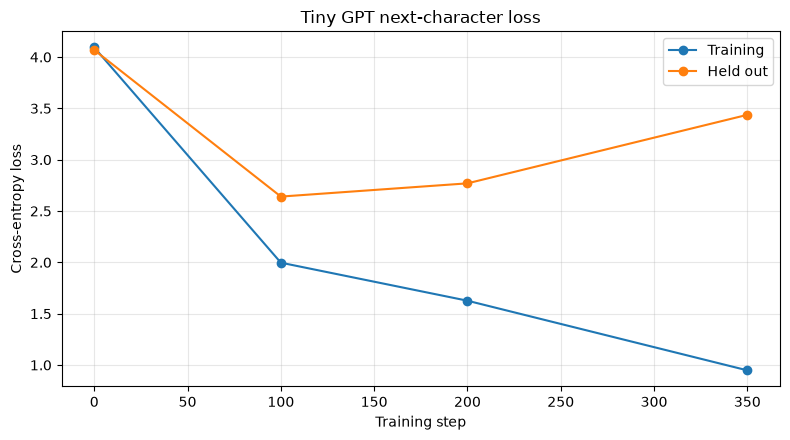

In [10]:
import matplotlib.pyplot as plt  # noqa: I001


plt.figure(figsize=(8, 4.5))
plt.plot(evaluation_steps, training_loss_history, marker="o", label="Training")
plt.plot(evaluation_steps, validation_loss_history, marker="o", label="Held out")
plt.xlabel("Training step")
plt.ylabel("Cross-entropy loss")
plt.title("Tiny GPT next-character loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Training loss falls at every evaluation, but held-out loss is lowest at step 100 and then rises.

That divergence is evidence of overfitting to the small repeated corpus.

Now inspect the controlled samples rather than inferring generation quality from loss alone.

In [11]:
for step in evaluation_steps:
    print("=" * 72)
    print("STEP", step)
    print(checkpoint_samples[step])

STEP 0
alice was1ne.:7kal1vluc?jot0y:1m9ydu8u0;i5!99wqkgjp:
qwxw!pg
xyz8,ixgg
j!z
yd zn4r561!wqi5p:95p,vs  !s0g
8
wc
STEP 100
alice wased sthed r l nd otthe we thee the ar w red the sapet
tthed ol ond.
t he rind tton w opnd e thed hok 
STEP 200
alice wased sted led hal bored lend cumond llernd te.
and ocked ck wind theyed ndrind tton wmop wie the llowa
STEP 350
alice wased n nind the win the re in imovend the win the the ral.
ive sthonyin ng the the moldshe lldse le be


Step 0 is mostly noise, while later checkpoints contain spaces, punctuation, and word-like fragments.

The later text is still malformed and repetitive, and step 350 is not a coherent improvement over every earlier sample.

This experiment demonstrates some local pattern learning, not understanding or long-range planning.

Repeated training text also means a fluent-looking span may be copied.

## Audit local, factual, and arithmetic prompts

The three prompts use the same trained model and sampling settings.

Only the first resembles the training task.

The other prompts test unsupported uses and should not be treated as a benchmark of broad language-model capability.

In [12]:
audit_prompts = {
    "local continuation": "alice was",
    "factual question": "who was the first president?",
    "arithmetic question": "if alice has 3 apples and gives 1 away,",
}
audit_samples = {
    label: generate_text(model, prompt, 120, random_seed=9510 + index)
    for index, (label, prompt) in enumerate(audit_prompts.items())
}

for label, sample in audit_samples.items():
    print("=" * 72)
    print(label.upper())
    print(sample)

LOCAL CONTINUATION
alice wasor ettesollled bled ck, lited sted anang nd he.
the moloruhe hurnd sthop shollllllllld ed led tedstenen back w he aorere
FACTUAL QUESTION
who was the first president?a r she iene beroneave.
shond thond the w r he rile eeeyonind the the the malld ritte, clieyon song ared tehe lowand ck 
ARITHMETIC QUESTION
if alice has 3 apples and gives 1 away, nd terisheroriseholied and the stehe s.
along wived ttthin rin the fieyothe rabake t s iton s nered tholle led, sowanie


None of these stored samples answers the factual or arithmetic prompt.

All three contain corpus-like fragments, showing that familiar surface continuation can persist even when the requested task changes.

An answer-shaped continuation would not by itself prove that the model retrieved a fact or executed arithmetic.

This model saw neither factual question-answer pairs nor arithmetic examples, and it received no instruction tuning.

## Check repetition and exact overlap

The next audit separates generated continuations from their prompts.

It reports repeated adjacent word pairs and the longest exact substring shared with the unrepeated training source.

Exact matching detects direct overlap but misses paraphrases and near-copies.

In [13]:
from collections import Counter  # noqa: I001
from dataclasses import dataclass


def longest_shared_substring(first_text: str, second_text: str) -> str:
    previous_lengths = [0] * (len(second_text) + 1)
    best_length = 0
    best_end = 0
    for first_index, first_character in enumerate(first_text, start=1):
        current_lengths = [0] * (len(second_text) + 1)
        for second_index, second_character in enumerate(second_text, start=1):
            if first_character == second_character:
                current_lengths[second_index] = previous_lengths[second_index - 1] + 1
                if current_lengths[second_index] > best_length:
                    best_length = current_lengths[second_index]
                    best_end = first_index
        previous_lengths = current_lengths
    return first_text[best_end - best_length : best_end]


@dataclass(frozen=True)
class SampleAudit:
    label: str
    repeated_word_pairs: int
    longest_exact_match: str


def audit_sample(label: str, prompt: str, generated_text: str) -> SampleAudit:
    continuation = generated_text[len(prompt) :]
    words = continuation.split()
    word_pairs = list(zip(words, words[1:], strict=False))
    pair_counts = Counter(word_pairs)
    repeated_pairs = sum(count - 1 for count in pair_counts.values() if count > 1)
    exact_match = longest_shared_substring(continuation, training_source_text)
    return SampleAudit(label, repeated_pairs, exact_match)


sample_audits = [
    audit_sample(label, audit_prompts[label], sample)
    for label, sample in audit_samples.items()
]
for audit in sample_audits:
    print(audit.label)
    print("  repeated adjacent word pairs:", audit.repeated_word_pairs)
    print("  longest exact training match length:", len(audit.longest_exact_match))
    print("  longest exact training match:", repr(audit.longest_exact_match))

local continuation
  repeated adjacent word pairs: 0
  longest exact training match length: 7
  longest exact training match: 'e.\nthe '
factual question
  repeated adjacent word pairs: 1
  longest exact training match length: 8
  longest exact training match: 'ond the '
arithmetic question
  repeated adjacent word pairs: 0
  longest exact training match length: 9
  longest exact training match: ' and the '


The longest matches here are only 7 to 9 characters and consist of common fragments.

These samples therefore show no long exact copy, although the check is too limited to establish originality.

A longer exact match would be a stronger copying warning than a common fragment such as `the`.

There is no universal safe threshold because common language, corpus size, and sample length all matter.

## Demonstrate the context boundary

During generation, `TinyGPT.generate` crops its input to the most recent 48 characters.

The next prompt places a secret near the beginning and then adds enough filler to push it outside that visible suffix.

In [14]:
long_prompt = (
    "the secret word is candle. "
    + "the garden was quiet. " * 5
    + "what is the secret word?"
)
visible_prompt = long_prompt[-model.context_length :]

print("full prompt length:", len(long_prompt))
print("visible context length:", len(visible_prompt))
print("visible context:", repr(visible_prompt))
print("'candle' is visible:", "candle" in visible_prompt)

full prompt length: 161
visible context length: 48
visible context: '. the garden was quiet. what is the secret word?'
'candle' is visible: False


The original occurrence of `candle` is absent from the tensor supplied for the next prediction.

The model could still emit that word by chance or from learned associations, but it cannot attend directly to the cropped occurrence.

This is a hard architectural boundary for this implementation, not evidence from a subjective sample review.

## Separate architecture from capability

The model uses authentic GPT-style computations, but capability depends on learned parameters and the evidence used to fit them.

The table records what this course demonstrated and what this run does not support.

In [15]:
@dataclass(frozen=True)
class CapabilityRow:
    capability: str
    status: str
    evidence_or_limit: str


capability_rows = [
    CapabilityRow(
        "Local character patterns",
        "demonstrated",
        "Checkpoint loss and controlled continuations provide direct evidence.",
    ),
    CapabilityRow(
        "Plausible names",
        "demonstrated in Chapter 91",
        "Short structure is learnable, but exact novelty checks remain necessary.",
    ),
    CapabilityRow(
        "Surface style differences",
        "demonstrated in Chapter 93",
        "Line breaks and punctuation can be learned; copying can look similar.",
    ),
    CapabilityRow(
        "Reliable factual answers",
        "not established",
        "No broad factual corpus, retrieval, or question-answer training was used.",
    ),
    CapabilityRow(
        "Reliable arithmetic reasoning",
        "not established",
        "No arithmetic procedure or instruction-following task was trained.",
    ),
    CapabilityRow(
        "Very long context",
        "not supported",
        "Only the most recent 48 characters enter each prediction.",
    ),
    CapabilityRow(
        "Coherent essays",
        "not established",
        "The experiment measures characters and short continuations, not essays.",
    ),
    CapabilityRow(
        "Production assistant",
        "not supported",
        "No application reliability, safety, latency, or monitoring target was met.",
    ),
]

print("capability".ljust(30), "status".ljust(26), "evidence or limit")
print("-" * 112)
for row in capability_rows:
    print(row.capability.ljust(30), row.status.ljust(26), row.evidence_or_limit)

capability                     status                     evidence or limit
----------------------------------------------------------------------------------------------------------------
Local character patterns       demonstrated               Checkpoint loss and controlled continuations provide direct evidence.
Plausible names                demonstrated in Chapter 91 Short structure is learnable, but exact novelty checks remain necessary.
Surface style differences      demonstrated in Chapter 93 Line breaks and punctuation can be learned; copying can look similar.
Reliable factual answers       not established            No broad factual corpus, retrieval, or question-answer training was used.
Reliable arithmetic reasoning  not established            No arithmetic procedure or instruction-following task was trained.
Very long context              not supported              Only the most recent 48 characters enter each prediction.
Coherent essays                not established     

## Why scale and training change behavior

Architecture specifies the operations available to a model.

Training determines the parameter values that use those operations.

Important capability inputs include:

- more varied data, which exposes more facts, tasks, and linguistic patterns;
- more model capacity, which can represent more structure but can also memorize;
- more optimization compute, which can fit that capacity more effectively;
- a longer trained context, which makes more prior tokens available;
- a tokenizer suited to the task, which changes sequence length and prediction units;
- instruction and preference training, which can teach response behavior;
- retrieval and tools, which can provide external or current information; and
- evaluation and operational safeguards, which are required for a defined deployment.

Increasing only one item does not guarantee a reliable system.

## Diagnose outputs honestly

Use this ordered review for any generated sample:

1. Record the corpus, tokenizer, model size, and context length.
2. Record the prompt, checkpoint, temperature, top-k, and random seed.
3. Identify specific local successes rather than saying the model understands.
4. Identify repetition, contradiction, topic loss, and malformed structure.
5. Check exact and near-exact overlap with training data.
6. Test many examples with a task-specific metric before claiming reliability.

Prefer: “The sample contains locally plausible spacing and word fragments.”

Avoid: “The model understands English.”

Prefer: “This factual task was not trained or validated.”

Avoid: “A plausible answer means the model knows the fact.”

## Takeaways

- The TinyGPT is a real next-token model with causal self-attention and learned parameters.
- This run demonstrates improving next-character prediction and local pattern generation.
- Chapters 91 and 93 showed that short names and surface style are accessible narrow tasks.
- Loss does not measure truth, reasoning, originality, safety, or long-form coherence.
- The 48-character context is a direct limit on what this model can attend to.
- A small repeated corpus makes memorization checks essential.
- Architecture alone does not determine capability; data, parameters, compute, context, post-training, tools, and evaluation all matter.
- This model is an educational miniature, not a production assistant.

The next engineering step is a reusable evaluation harness that records prompts, sampling settings, losses, overlap checks, and task-specific scores across checkpoints.